# San Diego County Transit Stop Density

This notebook visualizes the density of transit stops (MTS, NCTD, etc.) across San Diego County. For each census tract we count the number of GTFS transit stops that fall inside the tract polygon, divide by the tract's area, and plot the resulting density on a choropleth that ramps from **light blue (low density)** to **dark blue (high density)**.

**Inputs**
- `data/transit-stops-gtfs/data/Transit_Stops_GTFS.csv` &mdash; one row per transit stop, with `stop_lat` / `stop_lon` in WGS-84.
- `data/san-diego-census-geopandas/data/San Diego.csv` &mdash; one row per census tract in San Diego County, with a WKT `geometry` column in EPSG:26946.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

import shapely
from shapely import wkt
import geopandas as gpd

import warnings
warnings.simplefilter(action='ignore', category=Warning)

pd.set_option('display.max_columns', None)

## 1. Load the transit stops

The CSV stores latitude and longitude as decimal degrees (WGS-84, EPSG:4326). We turn each row into a point geometry.

In [12]:
stops_csv = r'C:\Users\aksha\OneDrive\Desktop\DS3\SmartRoutes\data\transit-stops-gtfs\data\Transit_Stops_GTFS.csv'
stops_df = pd.read_csv(stops_csv)
stops_df.columns = stops_df.columns.str.strip().str.lstrip('\ufeff')
print(f'Loaded {len(stops_df):,} transit stops')
stops_df.head()

Loaded 6,177 transit stops


,OID_,stop_UID,stop_agency,stop_id,stop_name,stop_lat,stop_lon,stop_code,location_type,parent_station,wheelchair_boarding,intersection_code,stop_place
0,1,MTS_11tbro,MTS,11tbro,11th Ave & Broadway,32.716268,-117.154649,NaN,1,NaN,0.0,NaN,NaN
1,2,MTS_12tS,MTS,12tS,12th & Imperial Station,32.706002,-117.153378,NaN,1,NaN,0.0,NaN,NaN
2,3,MTS_imtS,MTS,imtS,12th & Imperial Station Bayside,32.705229,-117.154318,NaN,1,NaN,0.0,NaN,NaN
3,4,MTS_imp12,MTS,imp12,12th & Imperial Transit Center,32.705685,-117.152875,NaN,1,NaN,0.0,NaN,NaN
4,5,MTS_24tS,MTS,24tS,24th Street Station,32.661854,-117.108017,NaN,1,NaN,0.0,NaN,NaN


In [13]:
stops_gdf = gpd.GeoDataFrame(
    stops_df,
    geometry=gpd.points_from_xy(stops_df['stop_lon'], stops_df['stop_lat']),
    crs='EPSG:4326',
)
stops_gdf[['stop_UID', 'stop_agency', 'stop_name', 'stop_lat', 'stop_lon', 'geometry']].head()

,stop_UID,stop_agency,stop_name,stop_lat,stop_lon,geometry
0,MTS_11tbro,MTS,11th Ave & Broadway,32.716268,-117.154649,POINT (-117.15465 32.71627)
1,MTS_12tS,MTS,12th & Imperial Station,32.706002,-117.153378,POINT (-117.15338 32.706)
2,MTS_imtS,MTS,12th & Imperial Station Bayside,32.705229,-117.154318,POINT (-117.15432 32.70523)
3,MTS_imp12,MTS,12th & Imperial Transit Center,32.705685,-117.152875,POINT (-117.15287 32.70568)
4,MTS_24tS,MTS,24th Street Station,32.661854,-117.108017,POINT (-117.10802 32.66185)


## 2. Load the census tract polygons

We reuse the San Diego census-tract polygons. The `geometry` column is stored as Well-Known Text (WKT). Despite what the original census notebook claims, the coordinates (e.g. `-13052014.93, 3867748.53`) are **EPSG:3857 (Web Mercator)** values, not EPSG:26946 — you can verify this by noting that `-13052014 ≈ -117.17° × 20037508 / 180`. So we tag the polygons as EPSG:3857, then reproject everything into EPSG:26946 (NAD83 / California zone 6, units = metres) so areas come out free of Mercator distortion.

In [ ]:
tracts_csv = r'C:\Users\aksha\OneDrive\Desktop\DS3\SmartRoutes\data\san-diego-census-geopandas\data\San Diego.csv'
tracts_df = pd.read_csv(tracts_csv, delimiter=',', encoding='ISO-8859-2')

tracts_gdf = gpd.GeoDataFrame(tracts_df.copy())
tracts_gdf['geometry'] = tracts_gdf['geometry'].apply(wkt.loads)
tracts_gdf = tracts_gdf.set_geometry('geometry')

# The WKT coordinates are actually Web Mercator (EPSG:3857), not EPSG:26946.
tracts_gdf = tracts_gdf.set_crs('EPSG:3857', allow_override=True)

# Reproject into a proper metric CRS for San Diego so .area is in real m^2.
tracts_gdf = tracts_gdf.to_crs('EPSG:26946')

tracts_gdf['area'] = tracts_gdf['NAME'].str.replace(
    ', San Diego County, California', '', regex=False
)

print('Tracts CRS:', tracts_gdf.crs.name)
print('Tract bounds (m):', tracts_gdf.total_bounds.round(0))
tracts_gdf[['GEOID', 'area', 'total_pop', 'geometry']].head()

## 3. Project the stops into the tract CRS and clip to the county

Reprojecting the stops into EPSG:26946 lets us do a spatial join in the same coordinate system as the tracts.

In [15]:
stops_proj = stops_gdf.to_crs(tracts_gdf.crs)

stops_in_county = gpd.sjoin(
    stops_proj, tracts_gdf[['GEOID', 'geometry']],
    how='inner', predicate='within',
)

print(f'{len(stops_in_county):,} of {len(stops_proj):,} stops fall inside a San Diego census tract')
stops_in_county[['stop_UID', 'stop_agency', 'stop_name', 'GEOID']].head()

0 of 6,177 stops fall inside a San Diego census tract


,stop_UID,stop_agency,stop_name,GEOID


## 4. Count stops per tract and compute density

Density is `stops per square kilometre`. EPSG:26946 is in metres, so we get area in m² from `.area` and divide by 1e6.

In [16]:
stops_per_tract = (
    stops_in_county.groupby('GEOID').size().rename('num_stops').reset_index()
)

density_gdf = tracts_gdf.merge(stops_per_tract, on='GEOID', how='left')
density_gdf['num_stops'] = density_gdf['num_stops'].fillna(0).astype(int)
density_gdf['area_km2'] = density_gdf.geometry.area / 1_000_000
density_gdf['stops_per_km2'] = density_gdf['num_stops'] / density_gdf['area_km2']

density_table = (
    density_gdf[['GEOID', 'area', 'num_stops', 'area_km2', 'stops_per_km2']]
    .sort_values('stops_per_km2', ascending=False)
    .reset_index(drop=True)
)
density_table.head(15)

,GEOID,area,num_stops,area_km2,stops_per_km2
0,6073007701,Census Tract 77.01,0,0.806838,0.0
1,6073008002,Census Tract 80.02,0,1.549549,0.0
2,6073007903,Census Tract 79.03,0,1.075406,0.0
3,6073008364,Census Tract 83.64,0,1.405888,0.0
4,6073008305,Census Tract 83.05,0,6.338052,0.0
5,6073009103,Census Tract 91.03,0,2.545557,0.0
6,6073008344,Census Tract 83.44,0,2.896904,0.0
7,6073000100,Census Tract 1,0,2.185453,0.0
8,6073010900,Census Tract 109,0,1.936849,0.0
9,6073008347,Census Tract 83.47,0,3.226349,0.0


In [17]:
# County-wide summary of stop density
density_table['stops_per_km2'].describe().round(3)

count    628.0
mean       0.0
std        0.0
min        0.0
25%        0.0
50%        0.0
75%        0.0
max        0.0
Name: stops_per_km2, dtype: float64

## 5. Choropleth: transit stop density (light blue → dark blue)

Matplotlib's built-in `Blues` colormap ramps from a very pale blue up to a deep navy, exactly matching the requested key.

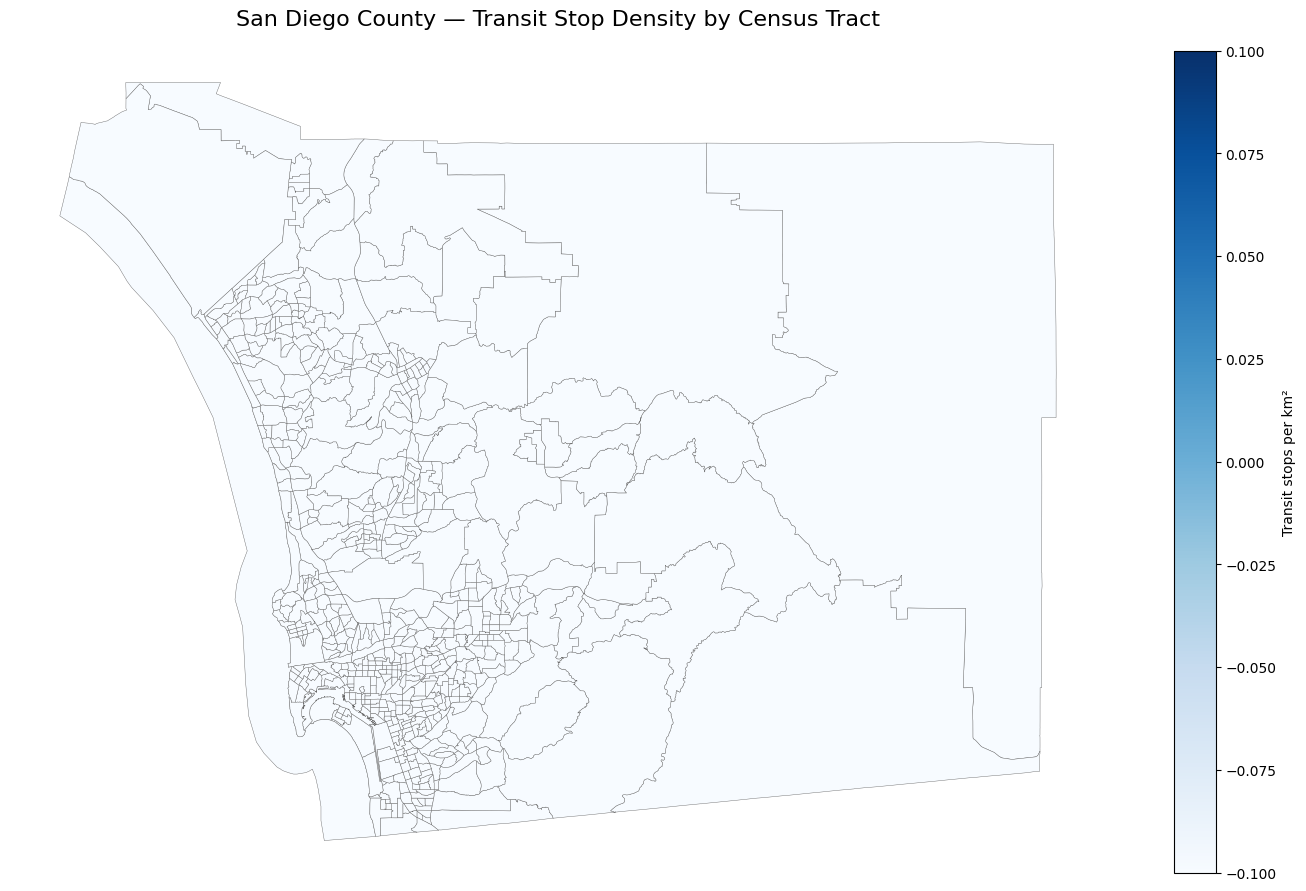

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

density_gdf.plot(
    column='stops_per_km2',
    cmap='Blues',
    linewidth=0.3,
    edgecolor='#666666',
    legend=True,
    legend_kwds={
        'label': 'Transit stops per km²',
        'orientation': 'vertical',
        'shrink': 0.6,
    },
    ax=ax,
)

ax.set_title('San Diego County — Transit Stop Density by Census Tract',
             fontsize=16, pad=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

### Custom light-blue → dark-blue ramp

The default `Blues` map skews toward the high end. Building a `LinearSegmentedColormap` with explicit endpoints (`#f7fbff` very pale, `#08306b` near-black navy) gives a smoother low-to-high gradient. We also use a `PowerNorm` so the long tail of dense urban tracts doesn't wash out everything else.

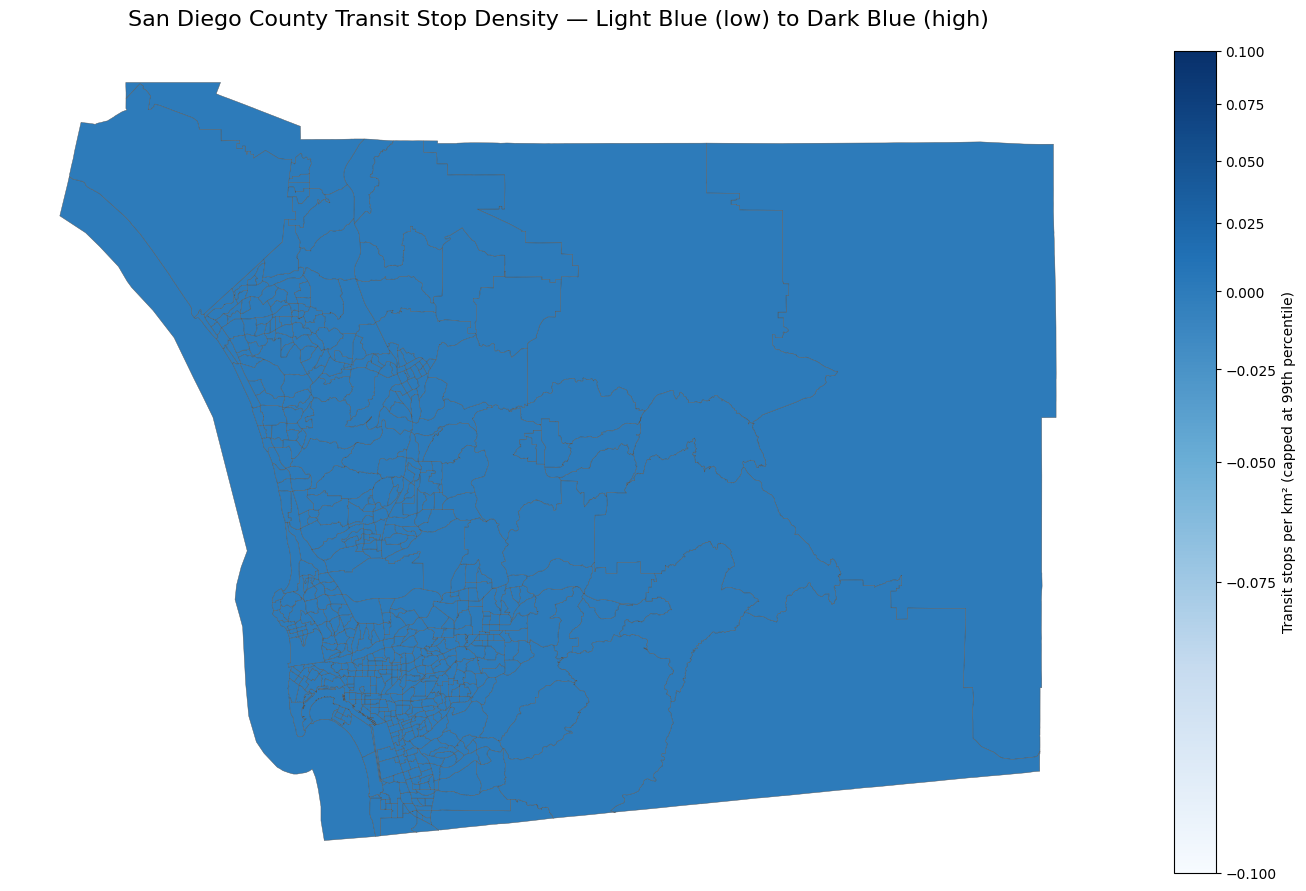

In [19]:
from matplotlib.colors import PowerNorm

light_to_dark_blue = LinearSegmentedColormap.from_list(
    'light_to_dark_blue',
    ['#f7fbff', '#c6dbef', '#6baed6', '#2171b5', '#08306b'],
)

vmax = density_gdf['stops_per_km2'].quantile(0.99)

fig, ax = plt.subplots(1, 1, figsize=(14, 14))
density_gdf.plot(
    column='stops_per_km2',
    cmap=light_to_dark_blue,
    norm=PowerNorm(gamma=0.5, vmin=0, vmax=vmax),
    linewidth=0.3,
    edgecolor='#555555',
    legend=True,
    legend_kwds={
        'label': 'Transit stops per km² (capped at 99th percentile)',
        'orientation': 'vertical',
        'shrink': 0.6,
    },
    missing_kwds={'color': 'lightgrey', 'label': 'No data'},
    ax=ax,
)
ax.set_title('San Diego County Transit Stop Density — Light Blue (low) to Dark Blue (high)',
             fontsize=16, pad=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Save the density table

Drop a CSV alongside the notebook so the per-tract stop counts and densities can be reused by other notebooks.

In [20]:
from pathlib import Path

output_dir = Path.cwd() / 'output_csvs'
output_dir.mkdir(parents=True, exist_ok=True)

out_path = output_dir / 'san_diego_transit_stop_density.csv'
density_table.to_csv(out_path, index=False)
print('Saved:', out_path)

Saved: c:\Users\aksha\OneDrive\Desktop\DS3\SmartRoutes\data\transit-stops-gtfs\notebook\output_csvs\san_diego_transit_stop_density.csv
